Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Load Dataset

In [2]:
df = pd.read_csv("sales_data.csv")
print(df.head())

         date     product     category   price  quantity  revenue
0  2022-01-01  Smartphone  Electronics   600.0      10.0   6000.0
1  2022-01-01      Laptop  Electronics  1200.0       5.0   6000.0
2  2022-01-02     T-Shirt     Clothing    20.0      50.0   1000.0
3  2022-01-03  Headphones  Electronics   100.0      20.0   2000.0
4  2022-01-04     T-Shirt     Clothing    20.0      25.0    500.0


Handle Missing Values

In [3]:
df = df.dropna()

Encode Categorical Data

In [4]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

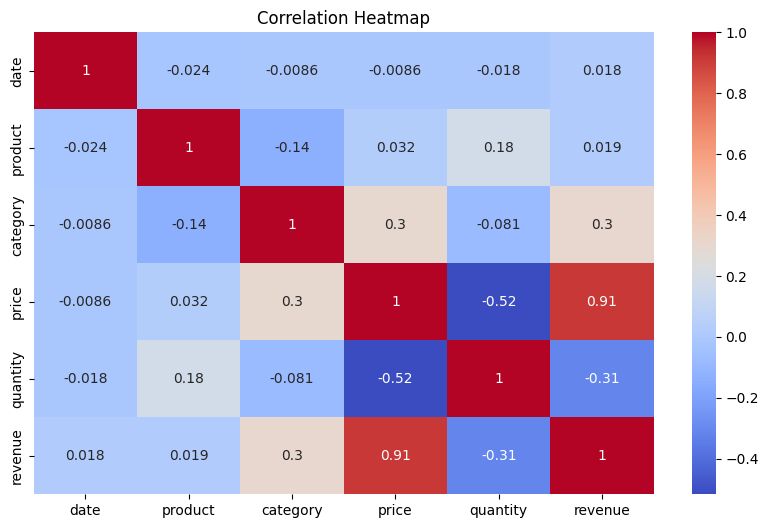

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

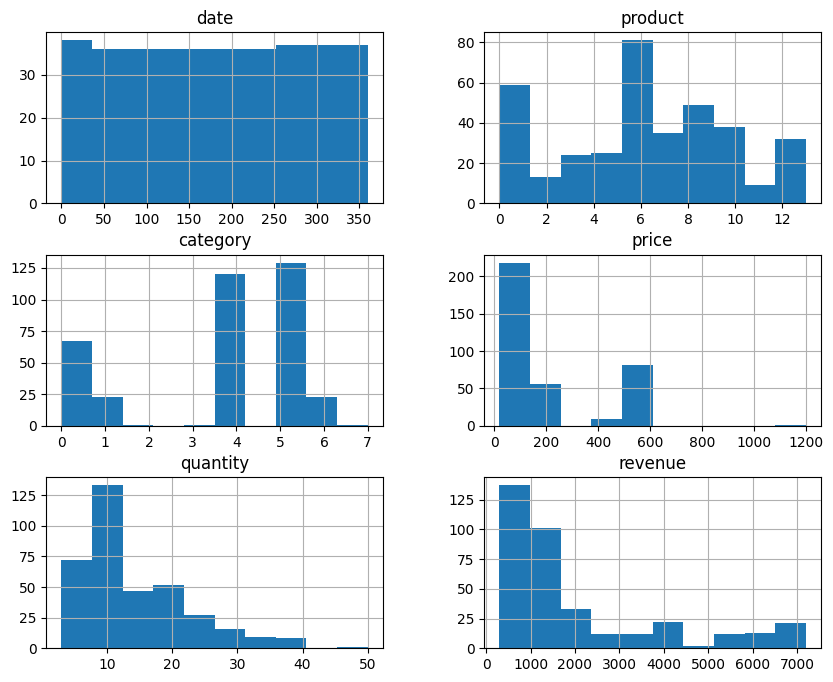

In [17]:
df.hist(figsize=(10,8))
plt.show()

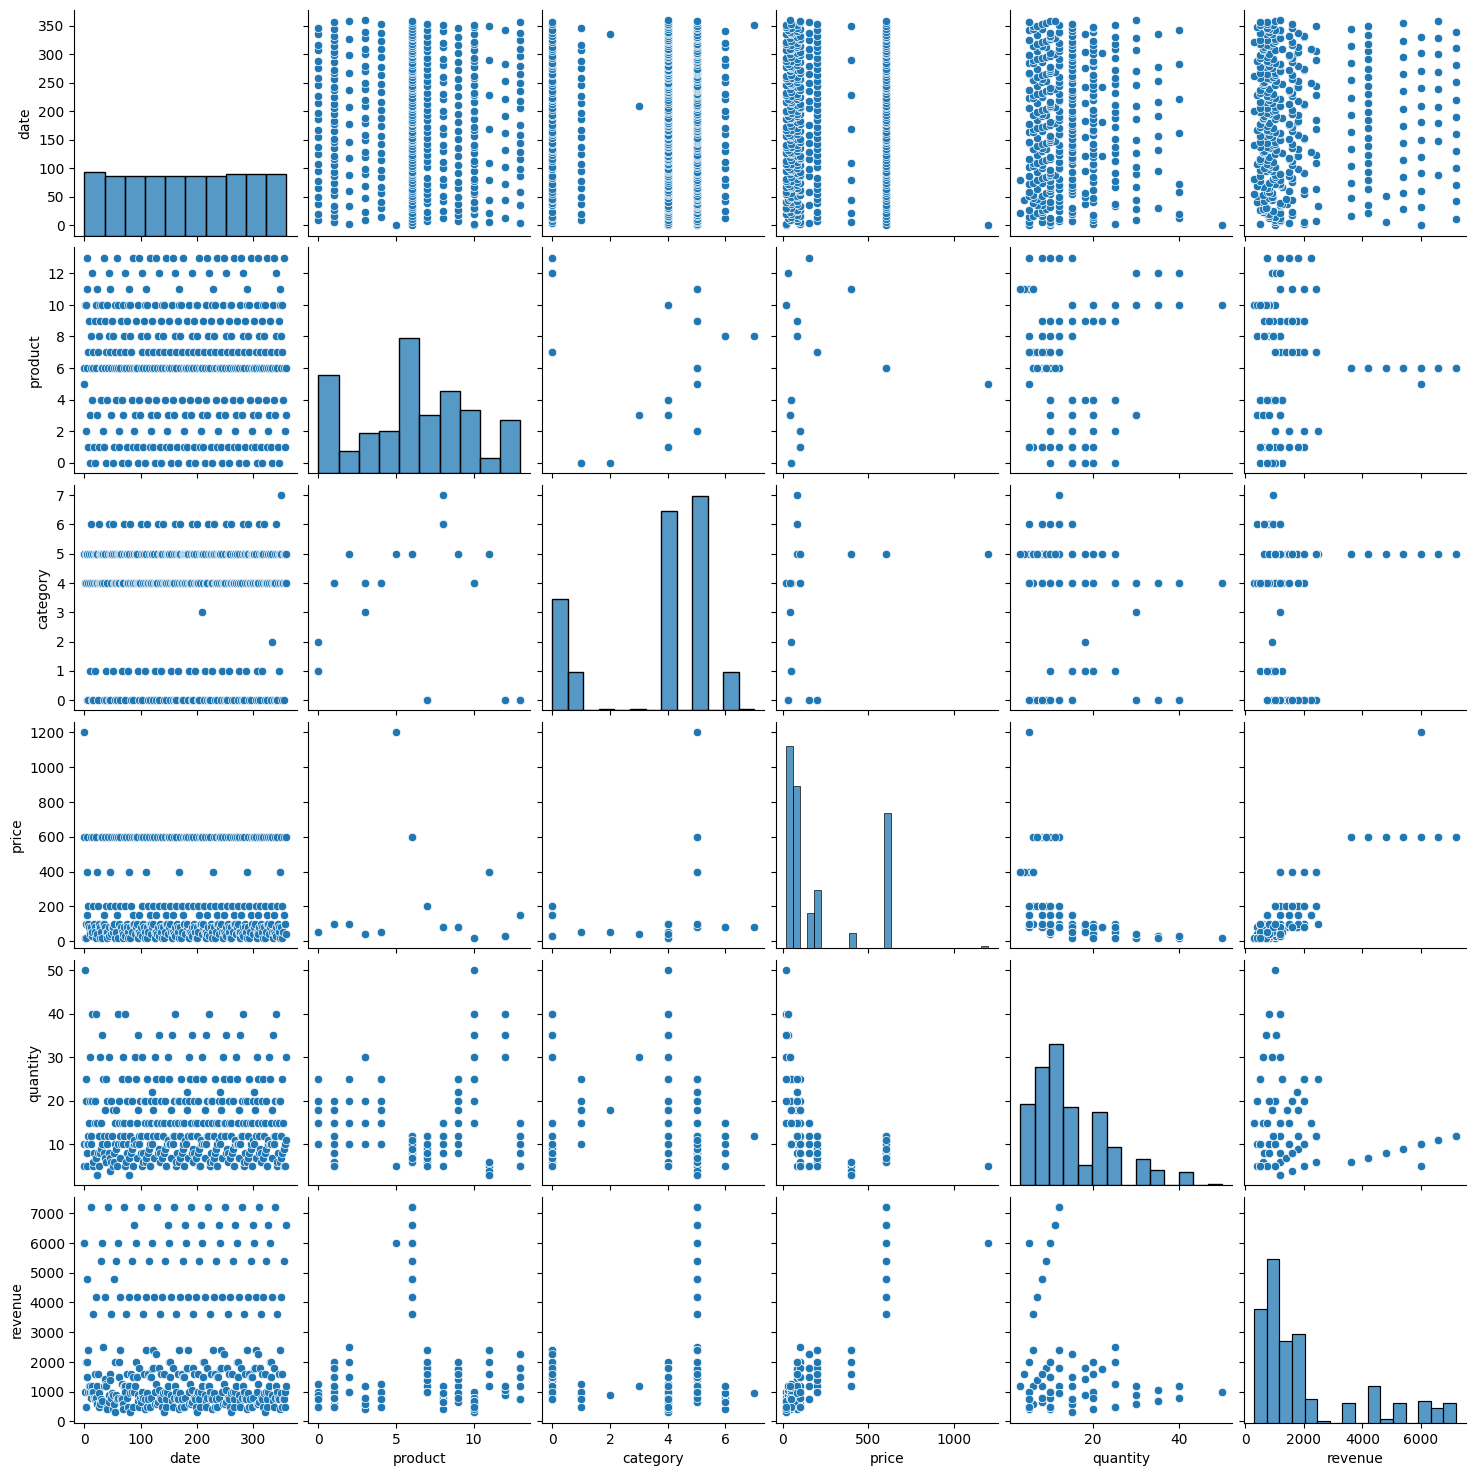

In [22]:
sns.pairplot(df)
plt.show()

Define Features & Target

In [6]:
X = df.drop("revenue", axis=1)
y = df["revenue"]

Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Linear Regression

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

Decision Tree

In [9]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

Random Forest

In [10]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [12]:
def evaluate(y_test, y_pred, model_name):
    print(f"\n{model_name}")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

In [13]:
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression
R2 Score: 0.889239585386761
MAE: 461.14054528818986
RMSE: 631.2065675012391

Decision Tree
R2 Score: 0.9976556777688017
MAE: 22.73972602739726
RMSE: 91.83069591552035

Random Forest
R2 Score: 0.998996192066946
MAE: 27.28219178082192
RMSE: 60.09032242645289


Visualization

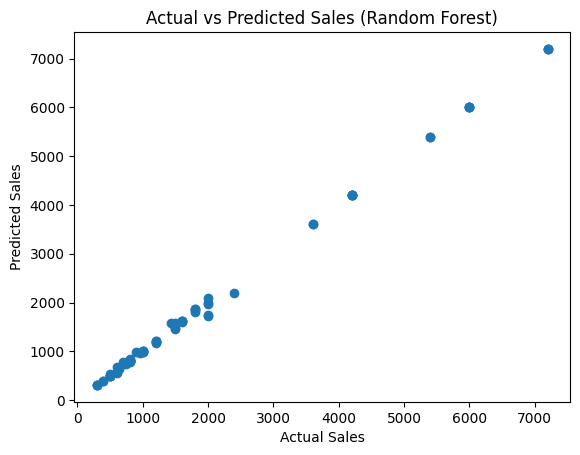

In [14]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest)")
plt.show()

Prediction

In [15]:
sample = X_test.iloc[0:1]
prediction = rf.predict(sample)
print("Predicted Sales:", prediction)

Predicted Sales: [640.]
